In [1]:
# ============================================================
# 0. OPTIONAL: LOAD DATASET FROM GOOGLE DRIVE
# ------------------------------------------------------------
# Runs only in Google Colab, and only when dataset.csv is not
# already present locally. Skipped silently in every other
# environment, so the notebook stays reproducible for anyone
# who clones this repository and supplies dataset.csv directly.
# ============================================================

import os
import shutil

DRIVE_CSV = "/content/drive/MyDrive/Big Data Analytics in Cloud/dataset.csv"

if os.path.exists("dataset.csv") or os.path.exists("/content/dataset.csv"):
    print("dataset.csv already present locally - skipping Google Drive.")
else:
    try:
        from google.colab import drive

        drive.mount("/content/drive")

        if os.path.exists(DRIVE_CSV):
            shutil.copy(DRIVE_CSV, "/content/dataset.csv")
            size_mb = os.path.getsize("/content/dataset.csv") / (1024 ** 2)
            print(f"Copied dataset.csv from Google Drive ({size_mb:.1f} MB).")
        else:
            print("File not found in Google Drive:")
            print(f"  {DRIVE_CSV}")
            print("Check the path, or upload dataset.csv to /content directly.")

    except ImportError:
        print("Not running in Google Colab - skipping Google Drive mount.")


Mounted at /content/drive
Copied dataset.csv from Google Drive (19.2 MB).


In [2]:
# ============================================================
# IST3134 GROUP ASSIGNMENT
# Spotify Big Data Analysis
# ============================================================

!pip -q install pyspark

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg,
    round as spark_round,
    count,
    col,
    when,
    sum as spark_sum,
    lit,
    pow as spark_pow,
    expr
)

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

os.makedirs("output", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

FEATURES = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness"
]

NUMERIC_COLS = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

CHECK_COLS = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo",
    "track_genre",
    "artists",
    "album_name",
    "track_name"
]

# Works both in Google Colab and when the notebook
# is downloaded/reused from GitHub.
if os.path.exists("dataset.csv"):
    DATA_PATH = "dataset.csv"
elif os.path.exists("/content/dataset.csv"):
    DATA_PATH = "/content/dataset.csv"
else:
    raise FileNotFoundError(
        "dataset.csv was not found. Upload the Spotify CSV "
        "dataset to Colab using the filename dataset.csv."
    )

print("Dataset path:", DATA_PATH)
print("Configuration completed successfully.")

Dataset path: dataset.csv
Configuration completed successfully.


In [4]:
# ============================================================
# 1. SPARK SESSION AND DATASET LOADING
# ============================================================

session_start = time.time()

spark = (
    SparkSession.builder
    .appName("SpotifyBigDataAnalysis")
    .getOrCreate()
)

session_startup_time = time.time() - session_start

# Important:
# DO NOT use multiLine=True.
# The FIX_LIST identified this as a problem because it prevents
# Spark from splitting the CSV efficiently.
df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True,
    quote='"',
    escape='"'
)

print("=" * 65)
print("DATASET LOADING AND OVERVIEW")
print("=" * 65)

print(f"\nSpark session startup time: {session_startup_time:.2f} seconds")
print(f"Partitions: {df.rdd.getNumPartitions()}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")

total_rows = df.count()

print("\n=== Dataset Overview ===")
print(f"Rows: {total_rows:,}")
print(f"Columns: {len(df.columns)}")

print("\n=== Columns ===")
print(df.columns)

print("\n=== Schema Before Cleaning ===")
df.printSchema()

print("\n=== First 5 Records ===")
df.show(5, truncate=False)

print("\nDataset loaded successfully.")

DATASET LOADING AND OVERVIEW

Spark session startup time: 13.51 seconds
Partitions: 2
Default parallelism: 2

=== Dataset Overview ===
Rows: 114,000
Columns: 21

=== Columns ===
['_c0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

=== Schema Before Cleaning ===
root
 |-- _c0: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- explicit: boolean (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = 

In [5]:
# ============================================================
# 2. DATA QUALITY CHECKS
# ============================================================

print("\n" + "=" * 65)
print("DATA QUALITY CHECKS")
print("=" * 65)

# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

print("\n=== Missing Value Check (PySpark) ===")

missing_counts = df.select([
    count(
        when(col(c).isNull(), 1)
    ).alias(c)
    for c in CHECK_COLS
])

missing_counts.show(truncate=False)

# Save result
missing_counts.coalesce(1).write.mode("overwrite") \
    .option("header", True) \
    .csv("output/missing_values_spark")

# ------------------------------------------------------------
# Duplicate track_id check
# ------------------------------------------------------------

print("\n=== Duplicate track_id Check (PySpark) ===")

total_count = df.count()

missing_track_ids = df.filter(
    col("track_id").isNull()
).count()

duplicate_groups = (
    df.filter(col("track_id").isNotNull())
      .groupBy("track_id")
      .count()
      .filter(col("count") > 1)
)

duplicate_extra_rows = (
    duplicate_groups
    .select(
        spark_sum(col("count") - 1).alias("duplicate_extra_rows")
    )
    .collect()[0]["duplicate_extra_rows"]
)

if duplicate_extra_rows is None:
    duplicate_extra_rows = 0

distinct_track_ids = (
    df.filter(col("track_id").isNotNull())
      .select("track_id")
      .distinct()
      .count()
)

print(f"Total rows: {total_count:,}")
print(f"Distinct non-null track_id values: {distinct_track_ids:,}")
print(f"Missing track_id values: {missing_track_ids:,}")
print(
    f"Repeated track_id rows beyond the first occurrence: "
    f"{int(duplicate_extra_rows):,}"
)

# ------------------------------------------------------------
# Dataset size verification
# ------------------------------------------------------------

print("\n=== Dataset Size Verification ===")
print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")

print("\n" + "=" * 65)
print("DATA QUALITY CHECKS COMPLETED SUCCESSFULLY")
print("=" * 65)


DATA QUALITY CHECKS

=== Missing Value Check (PySpark) ===
+----------+------------+------+--------+-------+-----+-----------+-------+----------+----------+
|popularity|danceability|energy|loudness|valence|tempo|track_genre|artists|album_name|track_name|
+----------+------------+------+--------+-------+-----+-----------+-------+----------+----------+
|0         |0           |0     |0       |0      |0    |0          |1      |1         |1         |
+----------+------------+------+--------+-------+-----+-----------+-------+----------+----------+


=== Duplicate track_id Check (PySpark) ===
Total rows: 114,000
Distinct non-null track_id values: 89,741
Missing track_id values: 0
Repeated track_id rows beyond the first occurrence: 24,259

=== Dataset Size Verification ===
Rows: 114,000
Columns: 21

DATA QUALITY CHECKS COMPLETED SUCCESSFULLY


In [6]:
# ============================================================
# 2.1 DATA CLEANING AND NUMERICAL TYPE CONVERSION
# ============================================================

print("\n" + "=" * 65)
print("DATA CLEANING AND TYPE CONVERSION")
print("=" * 65)

# ------------------------------------------------------------
# Convert numerical columns safely
# ------------------------------------------------------------

df_clean = df

for c in NUMERIC_COLS:
    df_clean = df_clean.withColumn(
        c,
        expr(f"try_cast(`{c}` as double)")
    )

print("\n=== Numerical Columns Converted ===")

for c in NUMERIC_COLS:
    print(f"{c:20s} -> {df_clean.schema[c].dataType}")

# ------------------------------------------------------------
# Count rows before cleaning
# ------------------------------------------------------------

original_cleaning_rows = df_clean.count()

# ------------------------------------------------------------
# Remove invalid numerical values and missing important text
# ------------------------------------------------------------

df_clean = df_clean.filter(
    (col("tempo") > 0) &
    (col("duration_ms") > 0) &
    col("track_genre").isNotNull() &
    col("artists").isNotNull() &
    col("album_name").isNotNull() &
    col("track_name").isNotNull() &
    col("popularity").isNotNull() &
    col("danceability").isNotNull() &
    col("energy").isNotNull() &
    col("loudness").isNotNull() &
    col("valence").isNotNull()
)

cleaned_rows = df_clean.count()
rows_removed = original_cleaning_rows - cleaned_rows

print("\n=== Cleaning Result ===")
print(f"Original rows: {original_cleaning_rows:,}")
print(f"Rows after cleaning: {cleaned_rows:,}")
print(f"Rows removed by cleaning: {rows_removed:,}")

# ------------------------------------------------------------
# Verify data types
# ------------------------------------------------------------

print("\n=== Schema After Cleaning ===")
df_clean.printSchema()

# ------------------------------------------------------------
# Verify invalid values
# ------------------------------------------------------------

invalid_tempo = df_clean.filter(
    col("tempo") <= 0
).count()

invalid_duration = df_clean.filter(
    col("duration_ms") <= 0
).count()

missing_important = df_clean.filter(
    col("track_genre").isNull() |
    col("popularity").isNull() |
    col("danceability").isNull() |
    col("energy").isNull() |
    col("loudness").isNull() |
    col("valence").isNull() |
    col("tempo").isNull()
).count()

print("\n=== Cleaning Verification ===")
print(f"Remaining tempo <= 0 rows: {invalid_tempo}")
print(f"Remaining duration_ms <= 0 rows: {invalid_duration}")
print(f"Remaining missing important rows: {missing_important}")

# ------------------------------------------------------------
# Save cleaned dataset
# ------------------------------------------------------------

df_clean.coalesce(1).write.mode("overwrite") \
    .option("header", True) \
    .csv("output/cleaned_dataset")

print("\nCleaned dataset saved to: output/cleaned_dataset")
print("Data cleaning completed successfully.")


DATA CLEANING AND TYPE CONVERSION

=== Numerical Columns Converted ===
popularity           -> DoubleType()
duration_ms          -> DoubleType()
danceability         -> DoubleType()
energy               -> DoubleType()
key                  -> DoubleType()
loudness             -> DoubleType()
mode                 -> DoubleType()
speechiness          -> DoubleType()
acousticness         -> DoubleType()
instrumentalness     -> DoubleType()
liveness             -> DoubleType()
valence              -> DoubleType()
tempo                -> DoubleType()
time_signature       -> DoubleType()

=== Cleaning Result ===
Original rows: 114,000
Rows after cleaning: 113,842
Rows removed by cleaning: 158

=== Schema After Cleaning ===
root
 |-- _c0: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: double (nullable = true)
 |-- duration_ms: double (

In [7]:
# ============================================================
# 3. PYSPARK BIG DATA ANALYSIS
# ============================================================

print("\n" + "=" * 65)
print("PYSPARK BIG DATA ANALYSIS")
print("=" * 65)

# Cache cleaned data for repeated analysis
df_clean.cache()
df_clean.count()

# ------------------------------------------------------------
# 3.1 Genre-level aggregation
# ------------------------------------------------------------

spark_compute_start = time.time()

genre_profile = (
    df_clean
    .groupBy("track_genre")
    .agg(
        spark_round(
            avg("danceability"), 3
        ).alias("avg_danceability"),

        spark_round(
            avg("energy"), 3
        ).alias("avg_energy"),

        spark_round(
            avg("valence"), 3
        ).alias("avg_valence"),

        spark_round(
            avg("tempo"), 2
        ).alias("avg_tempo"),

        spark_round(
            avg("loudness"), 3
        ).alias("avg_loudness"),

        spark_round(
            avg("popularity"), 2
        ).alias("avg_popularity"),

        count("*").alias("track_count")
    )
    .orderBy(
        "avg_popularity",
        ascending=False
    )
)

print("\n=== Top 25 Genres by Average Popularity ===")
genre_profile.show(25, truncate=False)

genre_profile.coalesce(1).write.mode("overwrite") \
    .option("header", True) \
    .csv("output/genre_profile")

# ------------------------------------------------------------
# 3.2 Create unique-track dataset
# ------------------------------------------------------------

df_unique = (
    df_clean
    .dropDuplicates(["track_id"])
    .cache()
)

unique_rows = df_unique.count()

print("\n=== Unique Track Dataset ===")
print(f"Cleaned rows: {cleaned_rows:,}")
print(f"Unique track rows: {unique_rows:,}")

# ------------------------------------------------------------
# 3.3 Correlations - ONE Spark pass
# ------------------------------------------------------------

print("\n=== Correlation with Popularity ===")

assembler = VectorAssembler(
    inputCols=FEATURES + ["popularity"],
    outputCol="features"
)

vector_df = (
    assembler
    .transform(df_unique)
    .select("features")
)

correlation_matrix = (
    Correlation
    .corr(vector_df, "features")
    .head()[0]
    .toArray()
)

correlations = []

for i, feature in enumerate(FEATURES):
    corr_value = float(correlation_matrix[i, -1])
    correlations.append(
        (feature, corr_value)
    )

    print(
        f"{feature:15s} -> "
        f"corr with popularity: {corr_value:+.4f}"
    )

with open(
    "output/correlations.txt",
    "w"
) as f:

    for feature, corr_value in correlations:
        f.write(
            f"{feature}: {corr_value:+.4f}\n"
        )

# ------------------------------------------------------------
# 3.4 Exact 75th percentile
# ------------------------------------------------------------

threshold = df_unique.approxQuantile(
    "popularity",
    [0.75],
    0.0
)[0]

print(
    f"\nPopularity threshold "
    f"(75th percentile): {threshold:.2f}"
)

high_pop = df_unique.filter(
    col("popularity") >= threshold
)

low_pop = df_unique.filter(
    col("popularity") < threshold
)

# ------------------------------------------------------------
# 3.5 High popularity
# ------------------------------------------------------------

print("\n=== High-Popularity Group Averages ===")

high_pop_avg = high_pop.agg(
    spark_round(
        avg("danceability"), 3
    ).alias("avg_danceability"),

    spark_round(
        avg("energy"), 3
    ).alias("avg_energy"),

    spark_round(
        avg("valence"), 3
    ).alias("avg_valence")
)

high_pop_avg.show()

# ------------------------------------------------------------
# 3.6 Low popularity
# ------------------------------------------------------------

print("=== Low-Popularity Group Averages ===")

low_pop_avg = low_pop.agg(
    spark_round(
        avg("danceability"), 3
    ).alias("avg_danceability"),

    spark_round(
        avg("energy"), 3
    ).alias("avg_energy"),

    spark_round(
        avg("valence"), 3
    ).alias("avg_valence")
)

low_pop_avg.show()

spark_compute_elapsed = (
    time.time() - spark_compute_start
)

print(
    f"\nSpark computation time: "
    f"{spark_compute_elapsed:.2f} seconds"
)

print(
    f"Spark session startup time: "
    f"{session_startup_time:.2f} seconds"
)

print(
    "\nPySpark main analysis completed successfully."
)


PYSPARK BIG DATA ANALYSIS

=== Top 25 Genres by Average Popularity ===
+-----------------+----------------+----------+-----------+---------+------------+--------------+-----------+
|track_genre      |avg_danceability|avg_energy|avg_valence|avg_tempo|avg_loudness|avg_popularity|track_count|
+-----------------+----------------+----------+-----------+---------+------------+--------------+-----------+
|pop-film         |0.597           |0.605     |0.529      |117.26   |-7.872      |59.28         |1000       |
|k-pop            |0.648           |0.676     |0.557      |119.22   |-6.468      |56.95         |999        |
|chill            |0.664           |0.427     |0.404      |115.48   |-10.461     |53.65         |1000       |
|sad              |0.692           |0.462     |0.422      |119.06   |-10.275     |52.38         |1000       |
|grunge           |0.457           |0.803     |0.4        |129.35   |-5.661      |49.59         |1000       |
|indian           |0.592           |0.567     |0

In [8]:
# ============================================================
# 3.7 GENRE VARIANCE ANALYSIS
# ============================================================

print("\n" + "=" * 65)
print("VARIANCE IN POPULARITY EXPLAINED BY GENRE")
print("=" * 65)

grand_mean = (
    df_unique
    .agg(avg("popularity"))
    .collect()[0][0]
)

group_stats = (
    df_unique
    .groupBy("track_genre")
    .agg(
        avg("popularity").alias("genre_mean"),
        count("*").alias("n")
    )
)

ss_between = (
    group_stats
    .select(
        spark_sum(
            col("n") *
            spark_pow(
                col("genre_mean") -
                lit(grand_mean),
                2
            )
        )
    )
    .collect()[0][0]
)

ss_total = (
    df_unique
    .select(
        spark_sum(
            spark_pow(
                col("popularity") -
                lit(grand_mean),
                2
            )
        )
    )
    .collect()[0][0]
)

eta_squared = ss_between / ss_total

strongest_feature = max(
    correlations,
    key=lambda x: abs(x[1])
)

strongest_feature_name = strongest_feature[0]
strongest_feature_corr = strongest_feature[1]

feature_variance = strongest_feature_corr ** 2

print(
    f"Variance in popularity explained by genre: "
    f"{eta_squared:.2%}"
)

print(
    f"Strongest audio-feature correlation: "
    f"{strongest_feature_name} "
    f"({strongest_feature_corr:+.4f})"
)

print(
    f"Variance explained by strongest audio feature: "
    f"{feature_variance:.2%}"
)

print(
    "\nInterpretation:"
)

print(
    "Genre explains substantially more variation in popularity "
    "than any single selected audio feature."
)

with open(
    "output/genre_variance.txt",
    "w"
) as f:

    f.write(
        f"Variance in popularity explained by genre: "
        f"{eta_squared:.2%}\n"
    )

    f.write(
        f"Strongest audio feature: "
        f"{strongest_feature_name}\n"
    )

    f.write(
        f"Strongest audio correlation: "
        f"{strongest_feature_corr:+.4f}\n"
    )

    f.write(
        f"Variance explained by strongest audio feature: "
        f"{feature_variance:.2%}\n"
    )


VARIANCE IN POPULARITY EXPLAINED BY GENRE
Variance in popularity explained by genre: 32.59%
Strongest audio-feature correlation: loudness (+0.0733)
Variance explained by strongest audio feature: 0.54%

Interpretation:
Genre explains substantially more variation in popularity than any single selected audio feature.


In [9]:
# ============================================================
# 3.8 EXPLICIT MAPREDUCE-STYLE IMPLEMENTATION
# ============================================================

print("\n" + "=" * 65)
print("MAPREDUCE-STYLE GENRE AGGREGATION")
print("=" * 65)

rdd_result = (
    df_clean
    .select(
        "track_genre",
        "popularity"
    )
    .rdd

    # MAP
    .map(
        lambda row: (
            row["track_genre"],
            (row["popularity"], 1)
        )
    )

    # REDUCE
    .reduceByKey(
        lambda a, b: (
            a[0] + b[0],
            a[1] + b[1]
        )
    )

    # Calculate average
    .map(
        lambda x: (
            x[0],
            x[1][0] / x[1][1],
            x[1][1]
        )
    )

    # Sort by popularity
    .sortBy(
        lambda x: x[1],
        ascending=False
    )
)

mapreduce_df = rdd_result.toDF(
    [
        "track_genre",
        "avg_popularity",
        "track_count"
    ]
)

print("\n=== Top 25 Genres ===")

mapreduce_df.show(
    25,
    truncate=False
)

mapreduce_df.coalesce(1).write.mode("overwrite") \
    .option("header", True) \
    .csv("output/mapreduce_genre")

print("\nMapReduce-style implementation completed successfully.")


MAPREDUCE-STYLE GENRE AGGREGATION

=== Top 25 Genres ===
+-----------------+------------------+-----------+
|track_genre      |avg_popularity    |track_count|
+-----------------+------------------+-----------+
|pop-film         |59.283            |1000       |
|k-pop            |56.952952952952955|999        |
|chill            |53.651            |1000       |
|sad              |52.379            |1000       |
|grunge           |49.594            |1000       |
|indian           |49.539            |1000       |
|anime            |48.772            |1000       |
|emo              |48.128            |1000       |
|sertanejo        |47.866            |1000       |
|pop              |47.576            |1000       |
|progressive-house|46.615            |1000       |
|piano            |45.273            |1000       |
|mandopop         |45.025            |1000       |
|deep-house       |44.808            |1000       |
|brazil           |44.67             |1000       |
|electronic       |44.32

In [10]:
# ============================================================
# 4. PANDAS IMPLEMENTATION FOR COMPARISON
# ============================================================

print("\n" + "=" * 65)
print("PANDAS IMPLEMENTATION")
print("=" * 65)

# Load the same CSV
pandas_load_start = time.time()

pdf = pd.read_csv(
    DATA_PATH
)

pandas_load_elapsed = (
    time.time() - pandas_load_start
)

# ------------------------------------------------------------
# Convert numerical columns
# ------------------------------------------------------------

for c in NUMERIC_COLS:
    pdf[c] = pd.to_numeric(
        pdf[c],
        errors="coerce"
    )

# ------------------------------------------------------------
# Apply same cleaning rules as Spark
# ------------------------------------------------------------

pdf_clean = pdf[
    (pdf["tempo"] > 0) &
    (pdf["duration_ms"] > 0) &
    (pdf["track_genre"].notna()) &
    (pdf["artists"].notna()) &
    (pdf["album_name"].notna()) &
    (pdf["track_name"].notna()) &
    (pdf["popularity"].notna()) &
    (pdf["danceability"].notna()) &
    (pdf["energy"].notna()) &
    (pdf["loudness"].notna()) &
    (pdf["valence"].notna())
].copy()

pdf_clean = pdf_clean.reset_index(drop=True)

print("\n=== Pandas Dataset ===")
print(f"Original rows: {len(pdf):,}")
print(f"Rows after cleaning: {len(pdf_clean):,}")
print(
    f"Rows removed: "
    f"{len(pdf) - len(pdf_clean):,}"
)

# ------------------------------------------------------------
# Start fair computation timer
# ------------------------------------------------------------

pandas_compute_start = time.time()

# ------------------------------------------------------------
# Genre aggregation
# ------------------------------------------------------------

genre_profile_pd = (
    pdf_clean
    .groupby("track_genre")
    .agg(
        avg_danceability=("danceability", "mean"),
        avg_energy=("energy", "mean"),
        avg_valence=("valence", "mean"),
        avg_tempo=("tempo", "mean"),
        avg_loudness=("loudness", "mean"),
        avg_popularity=("popularity", "mean"),
        track_count=("popularity", "size")
    )
    .sort_values(
        "avg_popularity",
        ascending=False
    )
)

genre_profile_pd = genre_profile_pd.round(
    {
        "avg_danceability": 3,
        "avg_energy": 3,
        "avg_valence": 3,
        "avg_tempo": 2,
        "avg_loudness": 3,
        "avg_popularity": 2
    }
)

print("\n=== Top 25 Genres by Average Popularity ===")
print(
    genre_profile_pd.head(25)
)

genre_profile_pd.to_csv(
    "output/genre_profile_pandas.csv"
)

# ------------------------------------------------------------
# Unique tracks
# ------------------------------------------------------------

pdf_unique = (
    pdf_clean
    .drop_duplicates(
        subset=["track_id"]
    )
    .copy()
)

print(
    f"\nUnique track rows: "
    f"{len(pdf_unique):,}"
)

# ------------------------------------------------------------
# Correlations
# ------------------------------------------------------------

print("\n=== Pandas Correlation with Popularity ===")

correlations_pd = {}

for feature in FEATURES:

    corr_value = (
        pdf_unique[feature]
        .corr(
            pdf_unique["popularity"]
        )
    )

    correlations_pd[feature] = corr_value

    print(
        f"{feature:15s} -> "
        f"corr with popularity: "
        f"{corr_value:+.4f}"
    )

with open(
    "output/correlations_pandas.txt",
    "w"
) as f:

    for feature, value in correlations_pd.items():

        f.write(
            f"{feature}: "
            f"{value:+.4f}\n"
        )

# ------------------------------------------------------------
# Exact 75th percentile
# ------------------------------------------------------------

threshold_pd = (
    pdf_unique["popularity"]
    .quantile(0.75)
)

print(
    f"\nPopularity threshold "
    f"(75th percentile): "
    f"{threshold_pd:.2f}"
)

high_pop_pd = pdf_unique[
    pdf_unique["popularity"] >= threshold_pd
]

low_pop_pd = pdf_unique[
    pdf_unique["popularity"] < threshold_pd
]

print("\n=== High-Popularity Group Averages ===")

print(
    high_pop_pd[
        [
            "danceability",
            "energy",
            "valence"
        ]
    ]
    .mean()
    .round(3)
)

print("\n=== Low-Popularity Group Averages ===")

print(
    low_pop_pd[
        [
            "danceability",
            "energy",
            "valence"
        ]
    ]
    .mean()
    .round(3)
)

pandas_compute_elapsed = (
    time.time() - pandas_compute_start
)

print(
    f"\nPandas computation time: "
    f"{pandas_compute_elapsed:.2f} seconds"
)

with open(
    "output/pandas_runtime.txt",
    "w"
) as f:

    f.write(
        f"Pandas computation time: "
        f"{pandas_compute_elapsed:.2f} seconds\n"
    )

    f.write(
        f"Rows processed: "
        f"{len(pdf_clean)}\n"
    )

print("\nPandas analysis completed successfully.")


PANDAS IMPLEMENTATION

=== Pandas Dataset ===
Original rows: 114,000
Rows after cleaning: 113,842
Rows removed: 158

=== Top 25 Genres by Average Popularity ===
                   avg_danceability  avg_energy  avg_valence  avg_tempo  \
track_genre                                                               
pop-film                      0.597       0.605        0.529     117.26   
k-pop                         0.648       0.676        0.557     119.22   
chill                         0.664       0.427        0.404     115.48   
sad                           0.692       0.462        0.422     119.06   
grunge                        0.457       0.803        0.400     129.35   
indian                        0.592       0.567        0.463     116.14   
anime                         0.537       0.674        0.434     123.53   
emo                           0.599       0.670        0.441     126.99   
sertanejo                     0.592       0.710        0.619     127.05   
pop          

In [11]:
# ============================================================
# 4.1 PYSPARK VS PANDAS COMPARISON
# ============================================================

print("\n" + "=" * 65)
print("PYSPARK VS PANDAS COMPUTATION TIME COMPARISON")
print("(Spark startup excluded from fair computation comparison)")
print("=" * 65)

print(
    f"\nPySpark computation time: "
    f"{spark_compute_elapsed:.2f} seconds"
)

print(
    f"Pandas computation time:  "
    f"{pandas_compute_elapsed:.2f} seconds"
)

print(
    f"Spark startup time:       "
    f"{session_startup_time:.2f} seconds"
)

if pandas_compute_elapsed < spark_compute_elapsed:

    faster = "Pandas"

    ratio = (
        spark_compute_elapsed /
        pandas_compute_elapsed
    )

else:

    faster = "PySpark"

    ratio = (
        pandas_compute_elapsed /
        spark_compute_elapsed
    )

print(
    f"\nFaster for this dataset: "
    f"{faster}"
)

print(
    f"Approximate runtime ratio: "
    f"{ratio:.2f}x"
)

# ------------------------------------------------------------
# Consistency check
# ------------------------------------------------------------

print("\n=== Comparison Consistency Check ===")

spark_rows = df_clean.count()
pandas_rows = len(pdf_clean)

print(
    f"PySpark rows: {spark_rows:,}"
)

print(
    f"Pandas rows:  {pandas_rows:,}"
)

same_row_count = (
    spark_rows == pandas_rows
)

print(
    f"Same cleaned row count: "
    f"{same_row_count}"
)

spark_unique_count = (
    df_unique.count()
)

pandas_unique_count = (
    len(pdf_unique)
)

print(
    f"\nPySpark unique track_id rows: "
    f"{spark_unique_count:,}"
)

print(
    f"Pandas unique track_id rows:  "
    f"{pandas_unique_count:,}"
)

same_unique_count = (
    spark_unique_count ==
    pandas_unique_count
)

print(
    f"Same unique track count: "
    f"{same_unique_count}"
)

if not same_row_count:
    raise ValueError(
        "PySpark and Pandas did not process "
        "the same number of cleaned rows."
    )

if not same_unique_count:
    raise ValueError(
        "PySpark and Pandas did not process "
        "the same number of unique track IDs."
    )

# Save comparison
with open(
    "output/runtime_comparison.txt",
    "w"
) as f:

    f.write(
        f"PySpark computation time: "
        f"{spark_compute_elapsed:.2f} seconds\n"
    )

    f.write(
        f"Pandas computation time: "
        f"{pandas_compute_elapsed:.2f} seconds\n"
    )

    f.write(
        f"Spark startup time: "
        f"{session_startup_time:.2f} seconds\n"
    )

    f.write(
        f"Faster for this dataset: "
        f"{faster}\n"
    )

    f.write(
        f"Approximate runtime ratio: "
        f"{ratio:.2f}x\n"
    )

    f.write(
        f"PySpark cleaned rows: "
        f"{spark_rows}\n"
    )

    f.write(
        f"Pandas cleaned rows: "
        f"{pandas_rows}\n"
    )

print("\nRuntime comparison completed successfully.")


PYSPARK VS PANDAS COMPUTATION TIME COMPARISON
(Spark startup excluded from fair computation comparison)

PySpark computation time: 29.16 seconds
Pandas computation time:  0.09 seconds
Spark startup time:       13.51 seconds

Faster for this dataset: Pandas
Approximate runtime ratio: 310.73x

=== Comparison Consistency Check ===
PySpark rows: 113,842
Pandas rows:  113,842
Same cleaned row count: True

PySpark unique track_id rows: 89,583
Pandas unique track_id rows:  89,583
Same unique track count: True

Runtime comparison completed successfully.



VISUALISATIONS


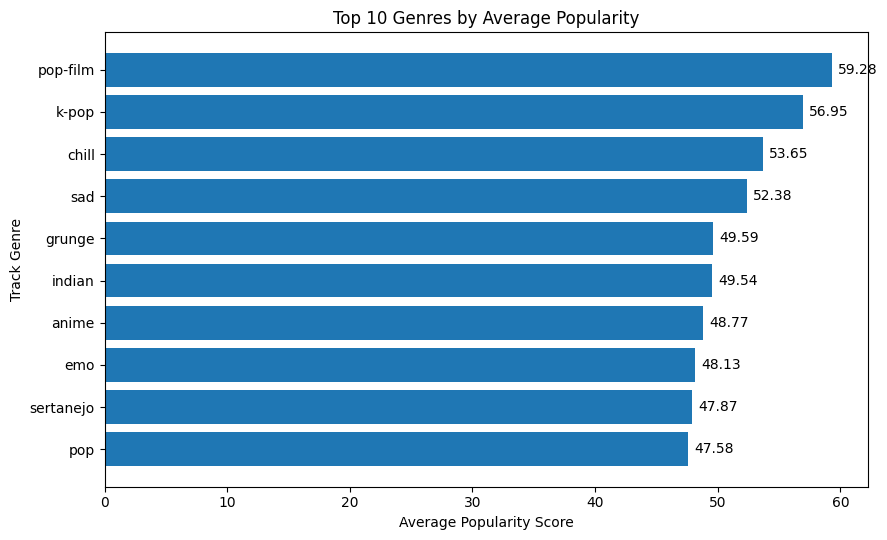

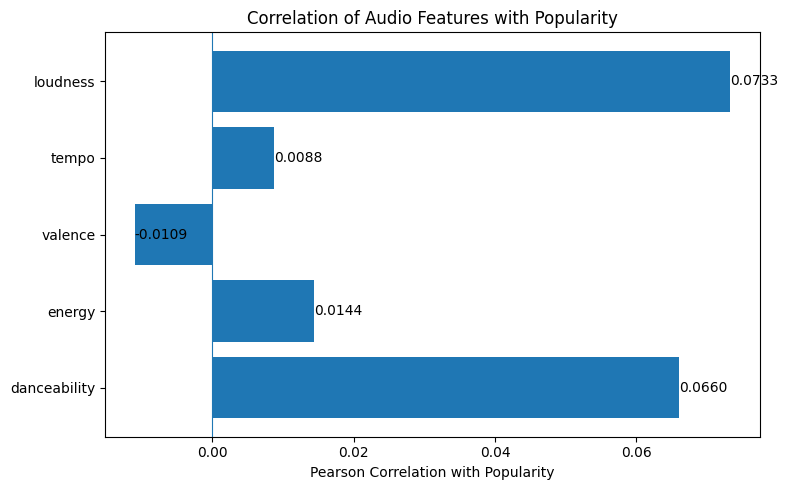

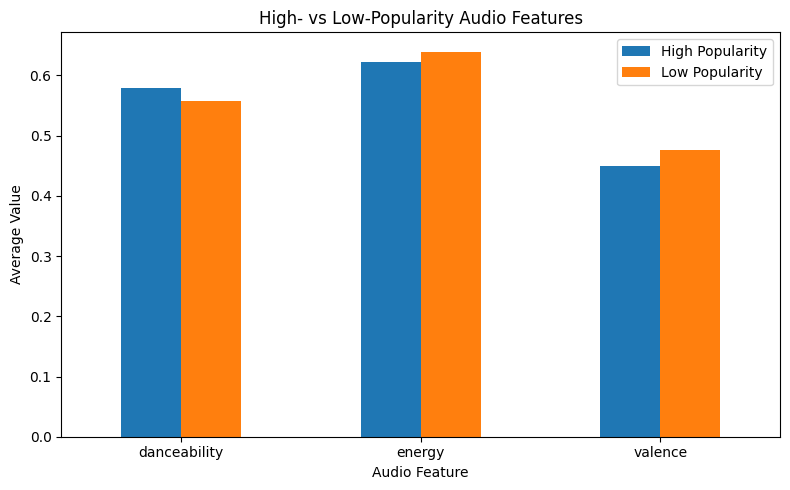

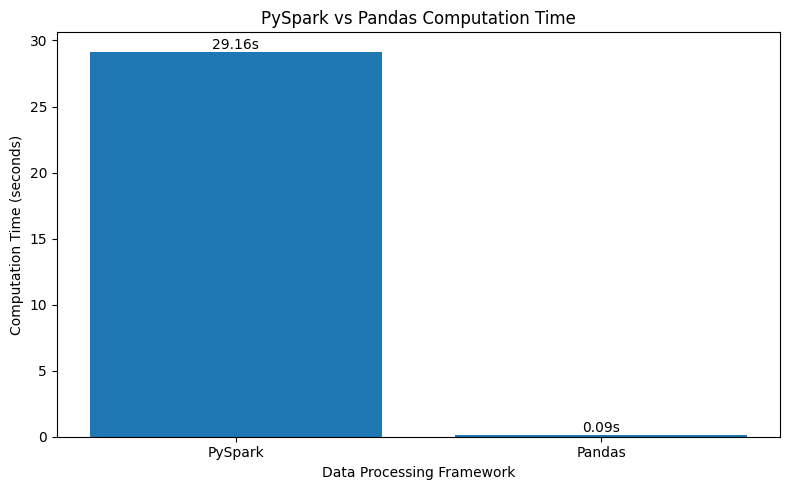

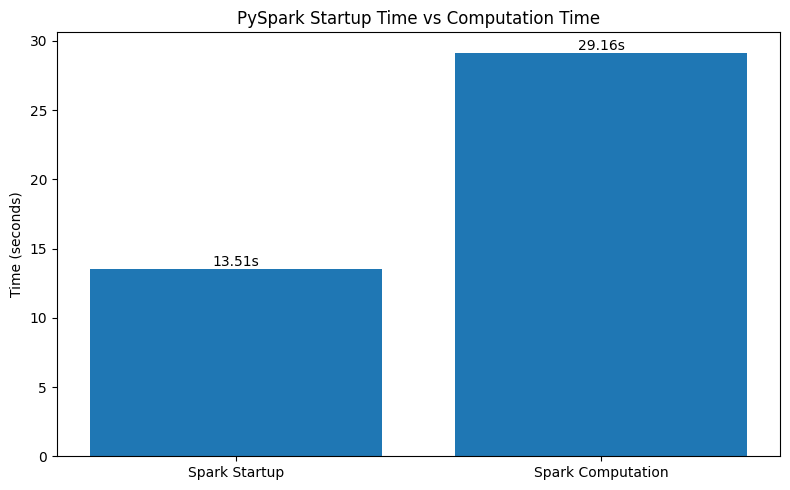

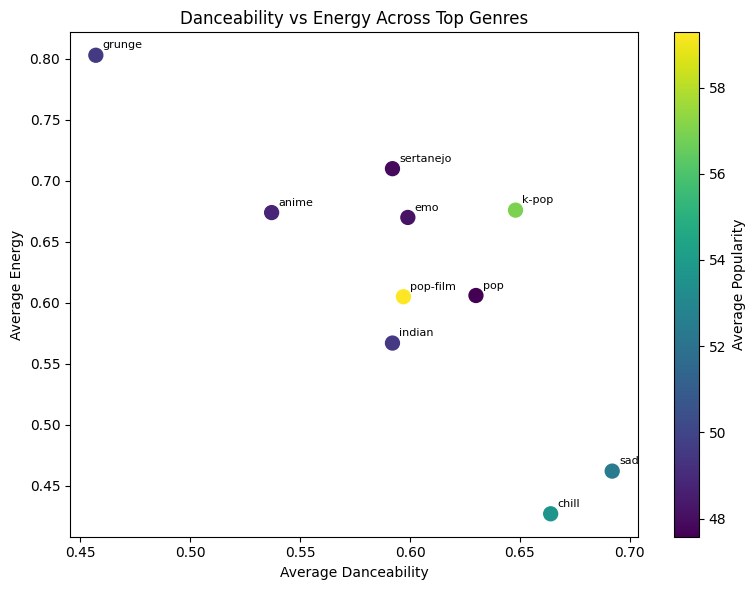


VISUALISATIONS COMPLETED

1. Top 10 genres by average popularity
2. Audio feature correlations with popularity
3. High vs low popularity comparison
4. PySpark vs Pandas runtime
5. Spark startup vs computation time
6. Danceability vs energy across top genres

All visualisation files were saved in the output folder.



In [12]:
# ============================================================
# 5. VISUALISATIONS
# ============================================================

print("\n" + "=" * 65)
print("VISUALISATIONS")
print("=" * 65)

# ------------------------------------------------------------
# Chart 1: Top 10 genres
# ------------------------------------------------------------

top10 = genre_profile_pd.head(10)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bars = ax.barh(
    top10.index[::-1],
    top10["avg_popularity"][::-1]
)

ax.set_xlabel(
    "Average Popularity Score"
)

ax.set_ylabel(
    "Track Genre"
)

ax.set_title(
    "Top 10 Genres by Average Popularity"
)

for bar, value in zip(
    bars,
    top10["avg_popularity"][::-1]
):

    ax.text(
        value + 0.5,
        bar.get_y() +
        bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "output/chart1_top_genres.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# Chart 2: Correlations
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5)
)

features_plot = list(
    correlations_pd.keys()
)

values_plot = list(
    correlations_pd.values()
)

bars = ax.barh(
    features_plot,
    values_plot
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel(
    "Pearson Correlation with Popularity"
)

ax.set_title(
    "Correlation of Audio Features with Popularity"
)

for bar, value in zip(
    bars,
    values_plot
):

    ax.text(
        value,
        bar.get_y() +
        bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "output/chart2_correlations.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# Chart 3: High vs Low Popularity
# ------------------------------------------------------------

high_means = (
    high_pop_pd[
        [
            "danceability",
            "energy",
            "valence"
        ]
    ]
    .mean()
)

low_means = (
    low_pop_pd[
        [
            "danceability",
            "energy",
            "valence"
        ]
    ]
    .mean()
)

comparison_df = pd.DataFrame(
    {
        "High Popularity": high_means,
        "Low Popularity": low_means
    }
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

comparison_df.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel(
    "Audio Feature"
)

ax.set_ylabel(
    "Average Value"
)

ax.set_title(
    "High- vs Low-Popularity Audio Features"
)

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "output/chart3_high_low_popularity.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# Chart 4: PySpark vs Pandas
# ------------------------------------------------------------

frameworks = [
    "PySpark",
    "Pandas"
]

times = [
    spark_compute_elapsed,
    pandas_compute_elapsed
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    frameworks,
    times
)

ax.set_xlabel(
    "Data Processing Framework"
)

ax.set_ylabel(
    "Computation Time (seconds)"
)

ax.set_title(
    "PySpark vs Pandas Computation Time"
)

for bar, value in zip(
    bars,
    times
):

    ax.text(
        bar.get_x() +
        bar.get_width() / 2,
        value,
        f"{value:.2f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "output/chart4_runtime_comparison.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# Chart 5: Spark startup vs computation
# ------------------------------------------------------------

labels = [
    "Spark Startup",
    "Spark Computation"
]

values = [
    session_startup_time,
    spark_compute_elapsed
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    labels,
    values
)

ax.set_ylabel(
    "Time (seconds)"
)

ax.set_title(
    "PySpark Startup Time vs Computation Time"
)

for bar, value in zip(
    bars,
    values
):

    ax.text(
        bar.get_x() +
        bar.get_width() / 2,
        value,
        f"{value:.2f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "output/chart5_spark_startup.png",
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# Chart 6: Danceability vs Energy
# ------------------------------------------------------------

top10_scatter = (
    genre_profile_pd
    .head(10)
    .copy()
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

scatter = ax.scatter(
    top10_scatter["avg_danceability"],
    top10_scatter["avg_energy"],
    s=100,
    c=top10_scatter["avg_popularity"]
)

for genre, row in top10_scatter.iterrows():

    ax.annotate(
        genre,
        (
            row["avg_danceability"],
            row["avg_energy"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel(
    "Average Danceability"
)

ax.set_ylabel(
    "Average Energy"
)

ax.set_title(
    "Danceability vs Energy Across Top Genres"
)

plt.colorbar(
    scatter,
    ax=ax,
    label="Average Popularity"
)

plt.tight_layout()

plt.savefig(
    "output/chart6_danceability_energy.png",
    dpi=150
)

plt.show()


print("\n" + "=" * 65)
print("VISUALISATIONS COMPLETED")
print("=" * 65)

print("""
1. Top 10 genres by average popularity
2. Audio feature correlations with popularity
3. High vs low popularity comparison
4. PySpark vs Pandas runtime
5. Spark startup vs computation time
6. Danceability vs energy across top genres

All visualisation files were saved in the output folder.
""")

In [13]:
# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

top_genre = (
    genre_profile_pd
    .iloc[0]
)

print("\n=== Dataset ===")
print(f"Original records: {total_rows:,}")
print(f"Cleaned records: {cleaned_rows:,}")
print(f"Unique tracks: {unique_rows:,}")
print(f"Rows removed during cleaning: {rows_removed:,}")

print("\n=== Genre Analysis ===")
print(
    f"Highest average-popularity genre: "
    f"{top_genre.name}"
)

print(
    f"Average popularity: "
    f"{top_genre['avg_popularity']:.2f}"
)

print("\n=== Correlation Analysis ===")

for feature, value in correlations:
    print(
        f"{feature:15s}: "
        f"{value:+.4f}"
    )

print("\n=== Strongest Audio Feature ===")
print(
    f"{strongest_feature_name}: "
    f"{strongest_feature_corr:+.4f}"
)

print("\n=== Genre Variance ===")
print(
    f"Popularity variance explained by genre: "
    f"{eta_squared:.2%}"
)

print("\n=== Popularity Threshold ===")
print(
    f"75th percentile: "
    f"{threshold:.2f}"
)

print("\n=== Runtime Comparison ===")
print(
    f"PySpark: "
    f"{spark_compute_elapsed:.2f} seconds"
)

print(
    f"Pandas: "
    f"{pandas_compute_elapsed:.2f} seconds"
)

print(
    f"Faster for this dataset: "
    f"{faster}"
)

print(
    f"Approximate ratio: "
    f"{ratio:.2f}x"
)

print("\n=== Consistency ===")
print(
    f"Same cleaned row count: "
    f"{same_row_count}"
)

print(
    f"Same unique track count: "
    f"{same_unique_count}"
)

print("\n" + "=" * 70)
print("SPOTIFY BIG DATA ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)


FINAL PROJECT SUMMARY

=== Dataset ===
Original records: 114,000
Cleaned records: 113,842
Unique tracks: 89,583
Rows removed during cleaning: 158

=== Genre Analysis ===
Highest average-popularity genre: pop-film
Average popularity: 59.28

=== Correlation Analysis ===
danceability   : +0.0660
energy         : +0.0144
valence        : -0.0109
tempo          : +0.0088
loudness       : +0.0733

=== Strongest Audio Feature ===
loudness: +0.0733

=== Genre Variance ===
Popularity variance explained by genre: 32.59%

=== Popularity Threshold ===
75th percentile: 49.00

=== Runtime Comparison ===
PySpark: 29.16 seconds
Pandas: 0.09 seconds
Faster for this dataset: Pandas
Approximate ratio: 310.73x

=== Consistency ===
Same cleaned row count: True
Same unique track count: True

SPOTIFY BIG DATA ANALYSIS COMPLETED SUCCESSFULLY
